# Plot quantum states

Visualize statevectors and density matrices using Qiskit.


## Package versions

The code on this page was developed using the following requirements. We recommend using these versions or newer.

```text
qiskit[all]~=2.5.1
```


In many situations, such as learning or debugging, it is helpful to visualize the state of a quantum computer. Here we assume you already have a particular state from simulation or state tomography. It is only possible to view the states of small quantum systems.

> **Tip: using the output from functions**
>
> All functions on this page return rich objects. When the last line of a code cell outputs these objects, Jupyter notebooks display them below the cell. If you call these functions in another environment or in a script, you may need to explicitly show or save the outputs.
>
> Most functions return images, which are `matplotlib.Figure` objects. You can call `.show()` on the returned object to open the image in a new window, or call `.savefig("out.png")` to save the figure to a file. For example, `plot_state_city(psi).savefig("out.png")`.
>
> LaTeX outputs are `IPython.display.Latex` objects. In a non-Jupyter environment, use a text representation or switch to the `latex_source` drawer to return a LaTeX source string.

A quantum state is either a density matrix $\rho$ (Hermitian matrix) or statevector $|\psi\rangle$ (complex vector). The density matrix is related to the statevector by

$$
\rho = |\psi\rangle\langle \psi|,
$$

and is more general, as it can represent mixed states (positive sums of statevectors):

$$
\rho = \sum_k p_k |\psi_k\rangle\langle \psi_k |.
$$

Qiskit represents quantum states through the `Statevector` and `DensityMatrix` classes and provides many visualization functions. The sections below show how Qiskit's different visualization functions plot the same quantum state.


In [21]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Create a Bell state for demonstration
qc = QuantumCircuit(2)
qc.h(0)
qc.crx(pi / 2, 0, 1)
psi = Statevector(qc)

## LaTeX

While not technically a plot, Qiskit can render LaTeX representations of both `Statevector` and `DensityMatrix` objects that display nicely in Jupyter notebooks. These follow the standard mathematical conventions for writing down quantum states.

Statevectors default to ket notation, whereas density matrices are displayed as matrices. You can also replace `"latex"` with `"latex_source"` to get the raw LaTeX string.


In [22]:
psi.draw("latex")  # psi is a Statevector object

<IPython.core.display.Latex object>

In [23]:
from qiskit.quantum_info import DensityMatrix

DensityMatrix(psi).draw("latex")  # convert to a DensityMatrix and draw

<IPython.core.display.Latex object>

## City plot

This plot displays the real and imaginary parts of each density matrix element in two three-dimensional bar charts. It is called a city plot because the bars resemble skyscrapers in a city. The state we are plotting has the following density matrix.

$$
\begin{bmatrix}
\frac{1}{2} & \frac{\sqrt{2}}{4} & 0 & \frac{\sqrt{2} i}{4}  \\
\frac{\sqrt{2}}{4} & \frac{1}{4} & 0 & \frac{i}{4}  \\
0 & 0 & 0 & 0  \\
- \frac{\sqrt{2} i}{4} & - \frac{i}{4} & 0 & \frac{1}{4}  \\
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2} & \frac{\sqrt{2}}{4} & 0 & 0 \\
\frac{\sqrt{2}}{4} & \frac{1}{4} & 0 & 0 \\
0 & 0 & 0 & 0  \\
0 & 0 & 0 & \frac{1}{4}  \\
\end{bmatrix}
+ i
\begin{bmatrix}
0 & 0 & 0 & \frac{\sqrt{2}}{4}  \\
0 & 0 & 0 & \frac{1}{4}  \\
0 & 0 & 0 & 0  \\
- \frac{\sqrt{2}}{4} & - \frac{1}{4} & 0 & 0 \\
\end{bmatrix}
$$


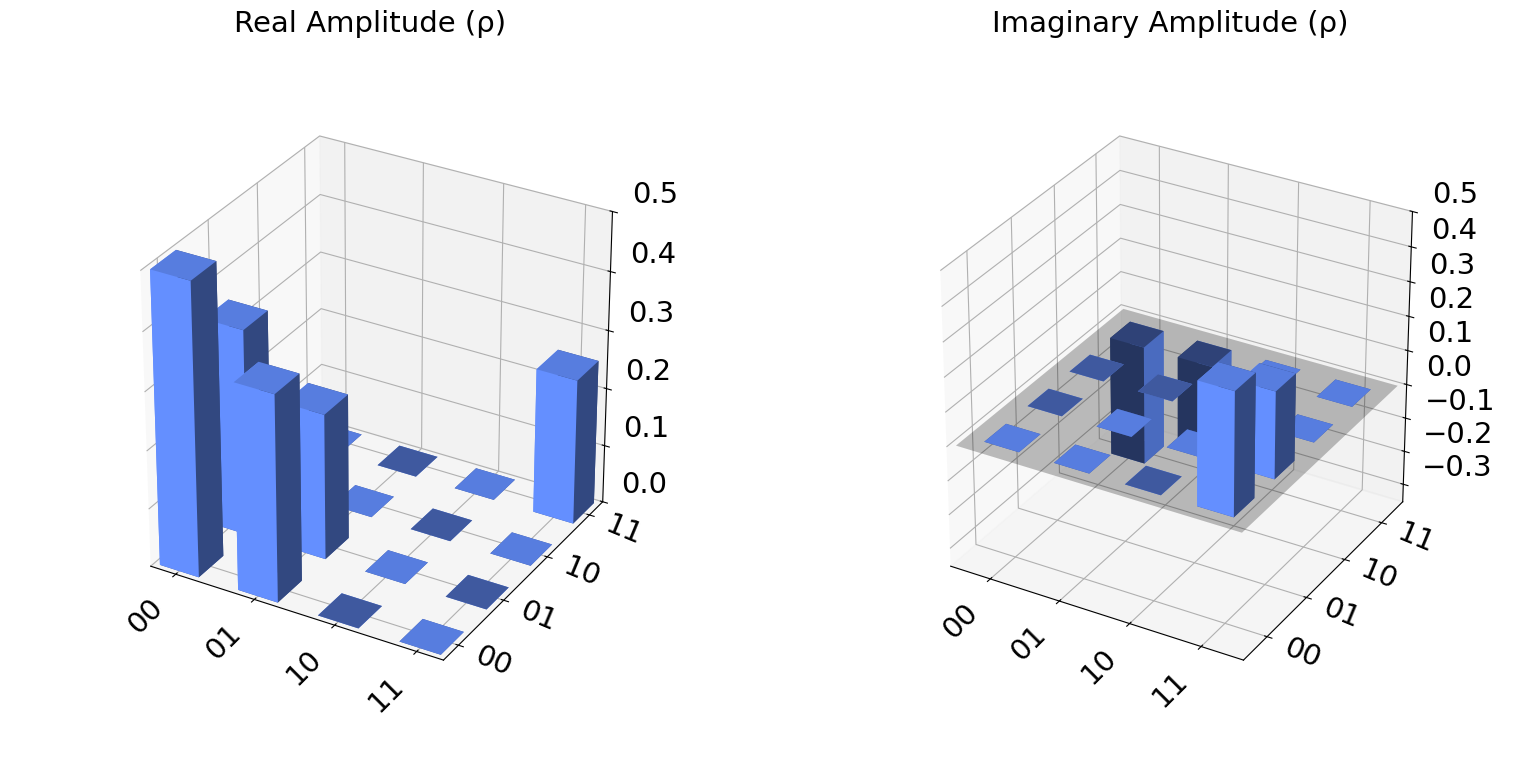

In [24]:
from qiskit.visualization import plot_state_city

plot_state_city(psi)
# Alternative: psi.draw("city")

## Hinton plot

This plot is very similar to the city plot, but the magnitude of each element is represented by the size of a square rather than the height of a bar. White squares represent elements with positive values, and black squares represent elements with negative values. The state we are plotting has the following density matrix.

$$
\begin{bmatrix}
\frac{1}{2} & \frac{\sqrt{2}}{4} & 0 & \frac{\sqrt{2} i}{4}  \\
\frac{\sqrt{2}}{4} & \frac{1}{4} & 0 & \frac{i}{4}  \\
0 & 0 & 0 & 0  \\
- \frac{\sqrt{2} i}{4} & - \frac{i}{4} & 0 & \frac{1}{4}  \\
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{2} & \frac{\sqrt{2}}{4} & 0 & 0 \\
\frac{\sqrt{2}}{4} & \frac{1}{4} & 0 & 0 \\
0 & 0 & 0 & 0  \\
0 & 0 & 0 & \frac{1}{4}  \\
\end{bmatrix}
+ i
\begin{bmatrix}
0 & 0 & 0 & \frac{\sqrt{2}}{4}  \\
0 & 0 & 0 & \frac{1}{4}  \\
0 & 0 & 0 & 0  \\
- \frac{\sqrt{2}}{4} & - \frac{1}{4} & 0 & 0 \\
\end{bmatrix}
$$


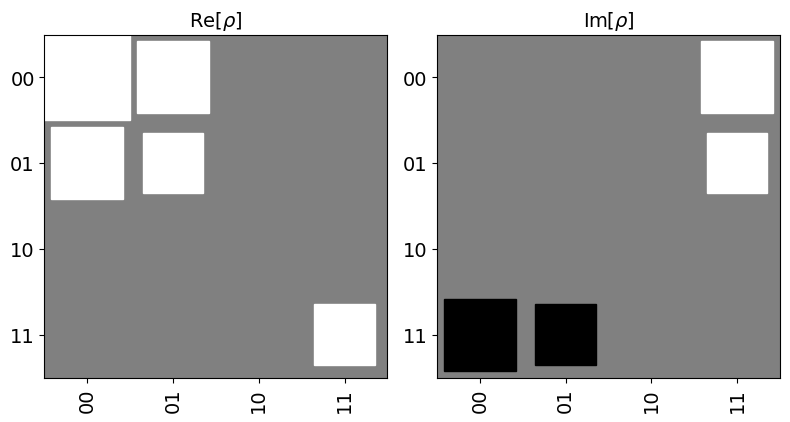

In [25]:
from qiskit.visualization import plot_state_hinton

plot_state_hinton(psi)
# Alternative: psi.draw("hinton")

## Pauli vector

An observable is a way of measuring a quantum state such that the possible measurement outcomes are real numbers. The expected value of the outcome is also known as the expectation value of the observable on that state, and it can be thought of as the average of infinitely many observations of that state.

Tensor products of Pauli matrices are all observables that return $+1$ or $-1$. This plot displays the expectation values of the state on different Pauli operators as a bar chart. All density matrices can be written as a sum of these Pauli matrices, weighted by their expectation values.

For example, this state can be written as the sum of terms:

$$
|\psi\rangle\langle\psi|
=
\tfrac{1}{4}II
+ \tfrac{\sqrt{2}}{8}IX
- \tfrac{\sqrt{2}}{8}XY
- \tfrac{1}{8}YI
- \tfrac{\sqrt{2}}{8}YX
+ \tfrac{1}{8}YZ
+ \tfrac{1}{8}ZI
+ \tfrac{\sqrt{2}}{8}ZX
+ \tfrac{1}{8}ZZ
$$

> **Pauli vector 값과 전개식 계수의 차이**
>
> `plot_state_paulivec(psi)`에 표시되는 막대값은 각 Pauli observable `P`에 대한 expectation value입니다.
>
> $$
> \langle P \rangle = \operatorname{Tr}(\rho P)
> $$
>
> 예를 들어 `II`는 identity observable이므로 모든 정상적인 quantum state에서
>
> $$
> \langle II \rangle = \operatorname{Tr}(\rho) = 1
> $$
>
> 입니다. 그래서 Pauli vector plot에서는 `II` 막대가 `1.0`으로 보입니다.
>
> 하지만 density matrix를 Pauli basis로 전개할 때는 qubit 수가 $n$개일 때 다음 normalization factor가 붙습니다.
>
> $$
> \rho = \frac{1}{2^n} \sum_P \langle P \rangle P
> $$
>
> 이 노트북은 2-qubit 상태이므로 $n=2$이고, 따라서 전개식의 계수는 plot 값의 $1/4$입니다. 즉 `II`는 plot에서는 `1.0`이지만 전개식에서는 $\frac{1}{4}II$로 나타납니다.



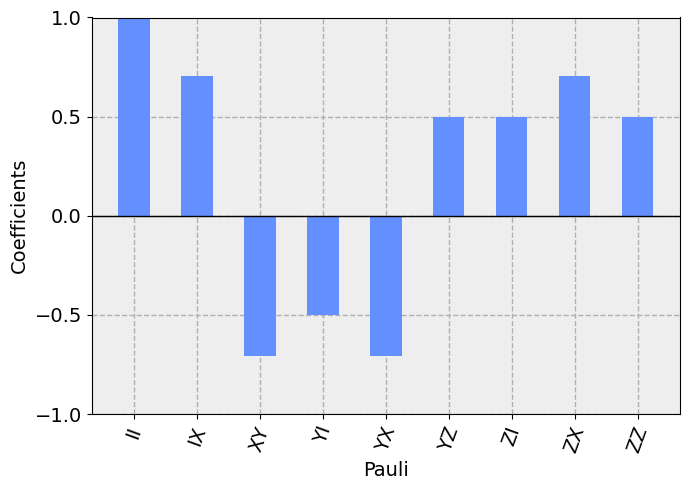

In [26]:
from qiskit.visualization import plot_state_paulivec

plot_state_paulivec(psi)
# Alternative: psi.draw("paulivec")

You can also calculate these coefficients using `SparsePauliOp`.


In [27]:
from qiskit.quantum_info import SparsePauliOp

SparsePauliOp.from_operator(psi)

SparsePauliOp(['II', 'IX', 'XY', 'YI', 'YX', 'YZ', 'ZI', 'ZX', 'ZZ'],
              coeffs=[ 0.25     +0.j,  0.1767767+0.j, -0.1767767+0.j, -0.125    +0.j,
 -0.1767767+0.j,  0.125    +0.j,  0.125    +0.j,  0.1767767+0.j,
  0.125    +0.j])

## Qsphere

The Qsphere is a Qiskit-unique view of a quantum state in which the amplitude and phase of each element in a statevector is plotted on the surface of a sphere. The thickness of each dot represents the amplitude, and the color represents the phase. For mixed states, it will show a sphere for each component.


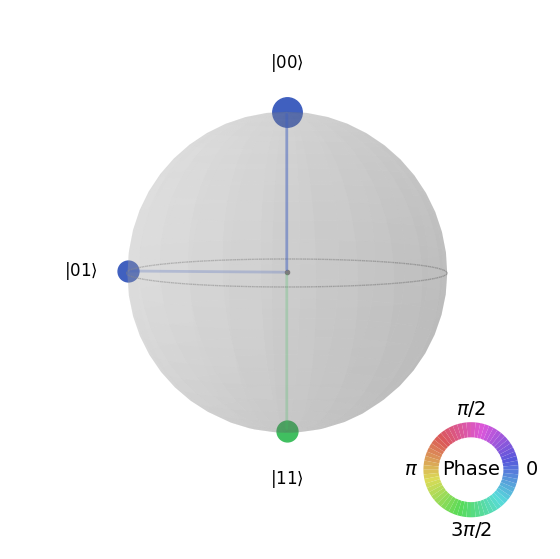

In [28]:
from qiskit.visualization import plot_state_qsphere

plot_state_qsphere(psi)
# Alternative: psi.draw("qsphere")

## Bloch

The Bloch vector of a qubit state is its expectation value in the X, Y, and Z Pauli observables mapped to the X, Y, and Z axes in three-dimensional space. This plot projects multi-qubit quantum states onto the single-qubit space and plots each qubit on a Bloch sphere. This visualization only shows the expectation values of individual qubits. It cannot show correlations between qubits, so it cannot fully describe entangled quantum states.


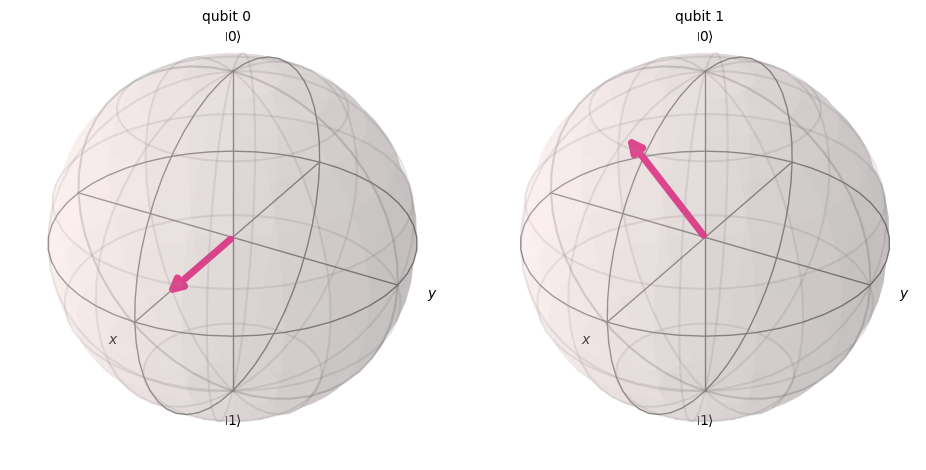

In [29]:
from qiskit.visualization import plot_bloch_multivector

plot_bloch_multivector(psi)
# Alternative: psi.draw("bloch")

## Options for state-plotting functions

All state-plotting functions accept the following arguments, except the LaTeX drawer, which does not return a Matplotlib figure, and `plot_state_qsphere`, which only accepts **figsize**.

- **title** (`str`): a string for the plot title, displayed at the top of the plot
- **figsize** (`tuple`): figure size in inches, as `(width, height)`

The `plot_state_city` and `plot_state_paulivec` functions also accept a **color** argument, which is a list of strings specifying the colors of the bars.


## Next steps

- Need to refresh your quantum information knowledge? Check out the [Basics of quantum information](/learning/courses/basics-of-quantum-information) course on IBM Quantum Learning.
- Read the [contributing guidelines](https://github.com/Qiskit/qiskit/blob/main/CONTRIBUTING.md) if you want to contribute to the open-source Qiskit SDK.
